# Exercise "multiprocessing"

In this exercise the harmonic sum

$$
\sum_{i=1}^{n}\frac{1}{i}
$$

is calculated using manual multithreading in C++.

The interval of summation is divided into smaller subintervals, and each thread calculates a partial sum. After all threads have finished, the partial sums are added together to obtain the final result.

The program is then timed for different numbers of threads in order to investigate whether the calculation becomes faster when the work is distributed over several processor cores.

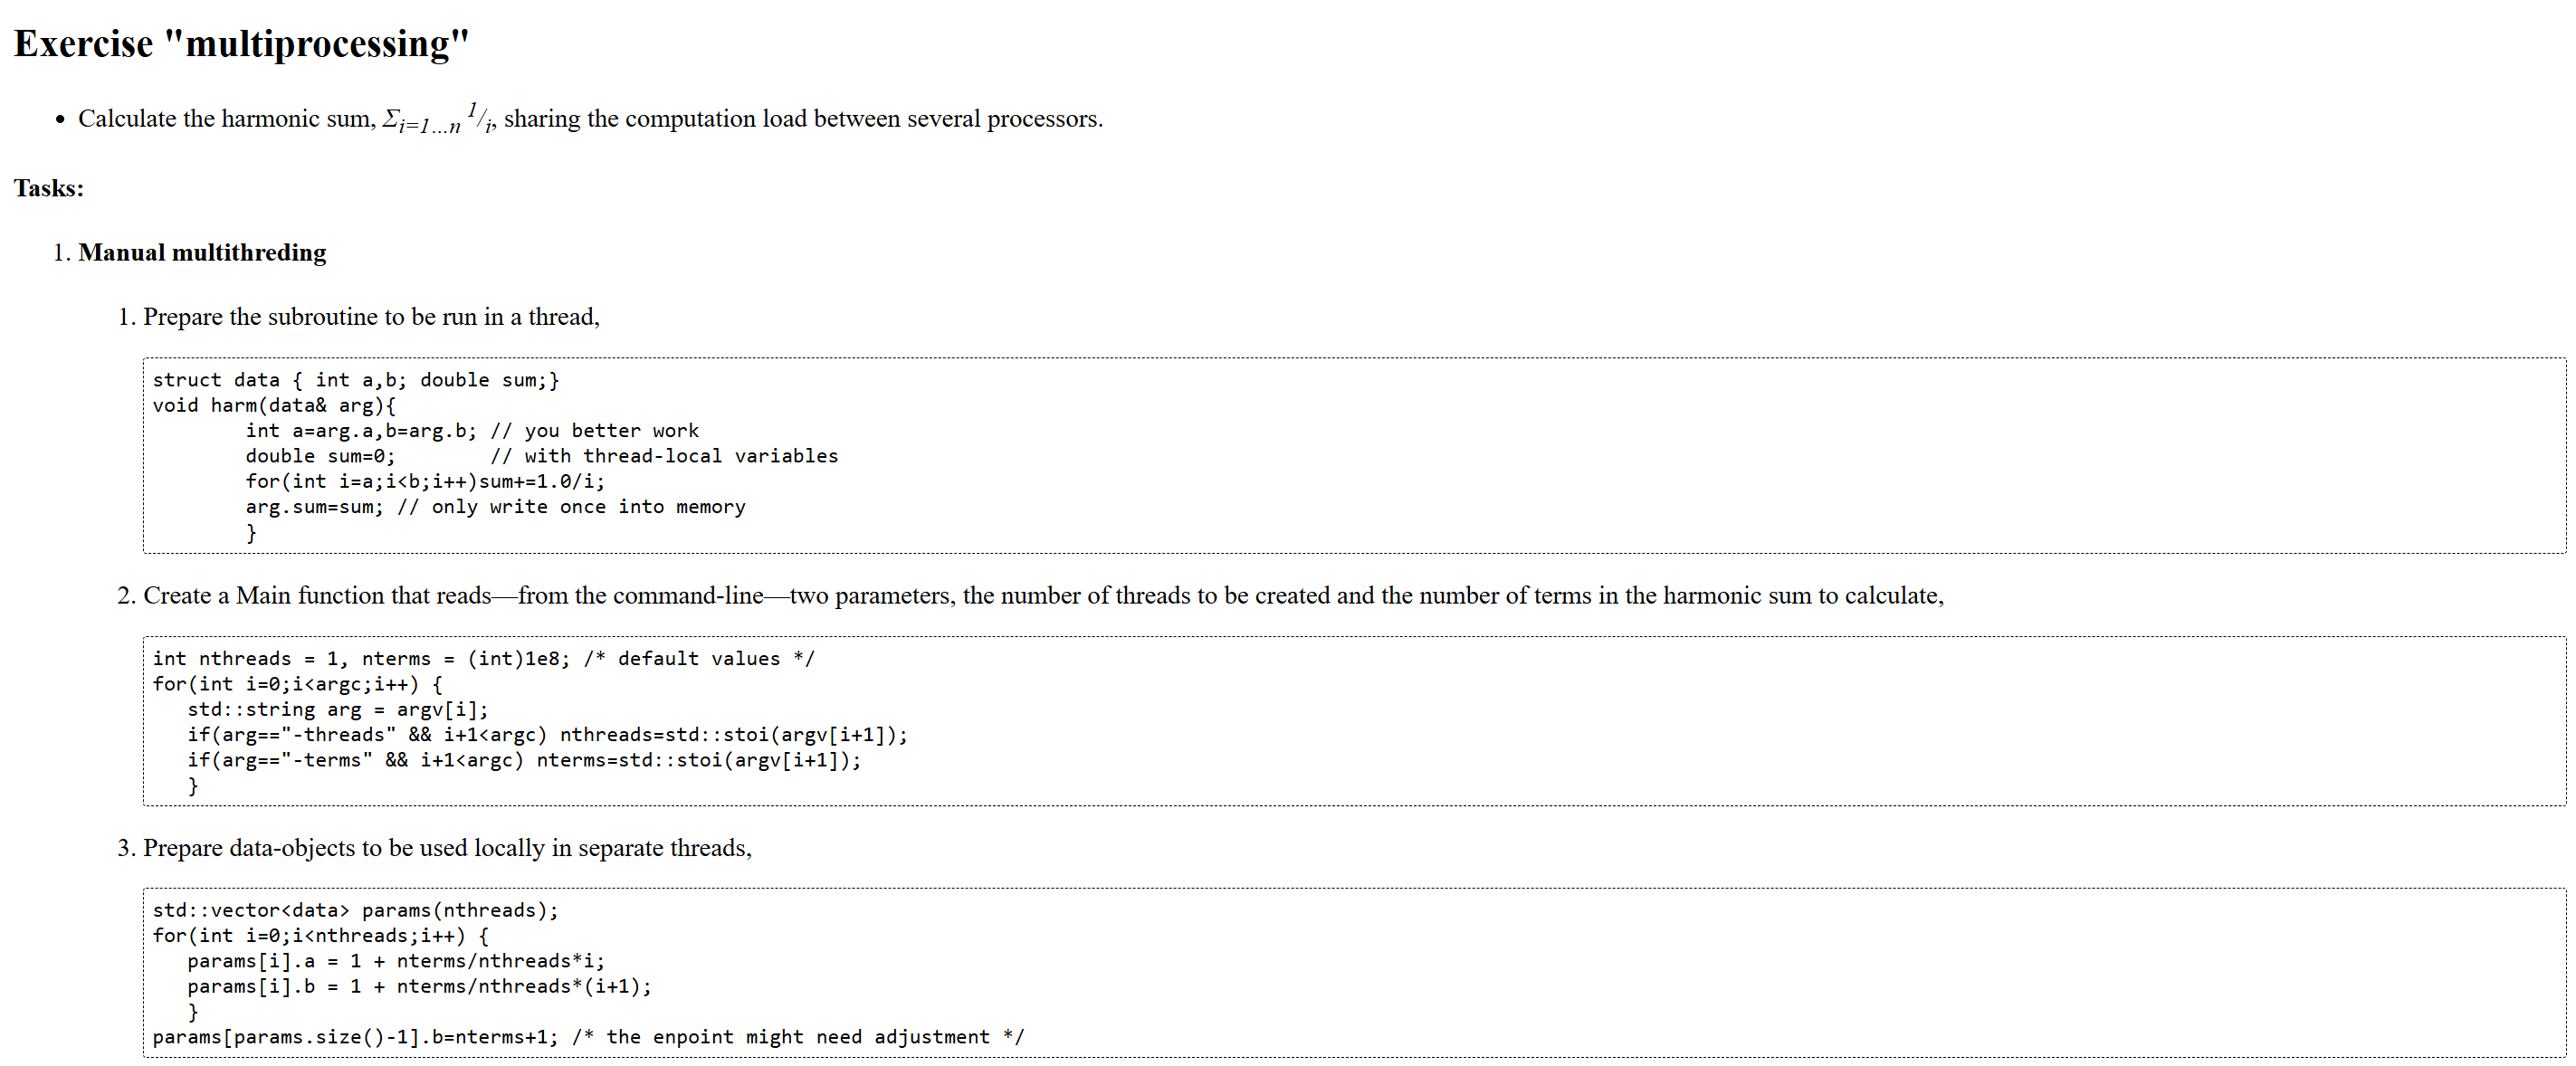

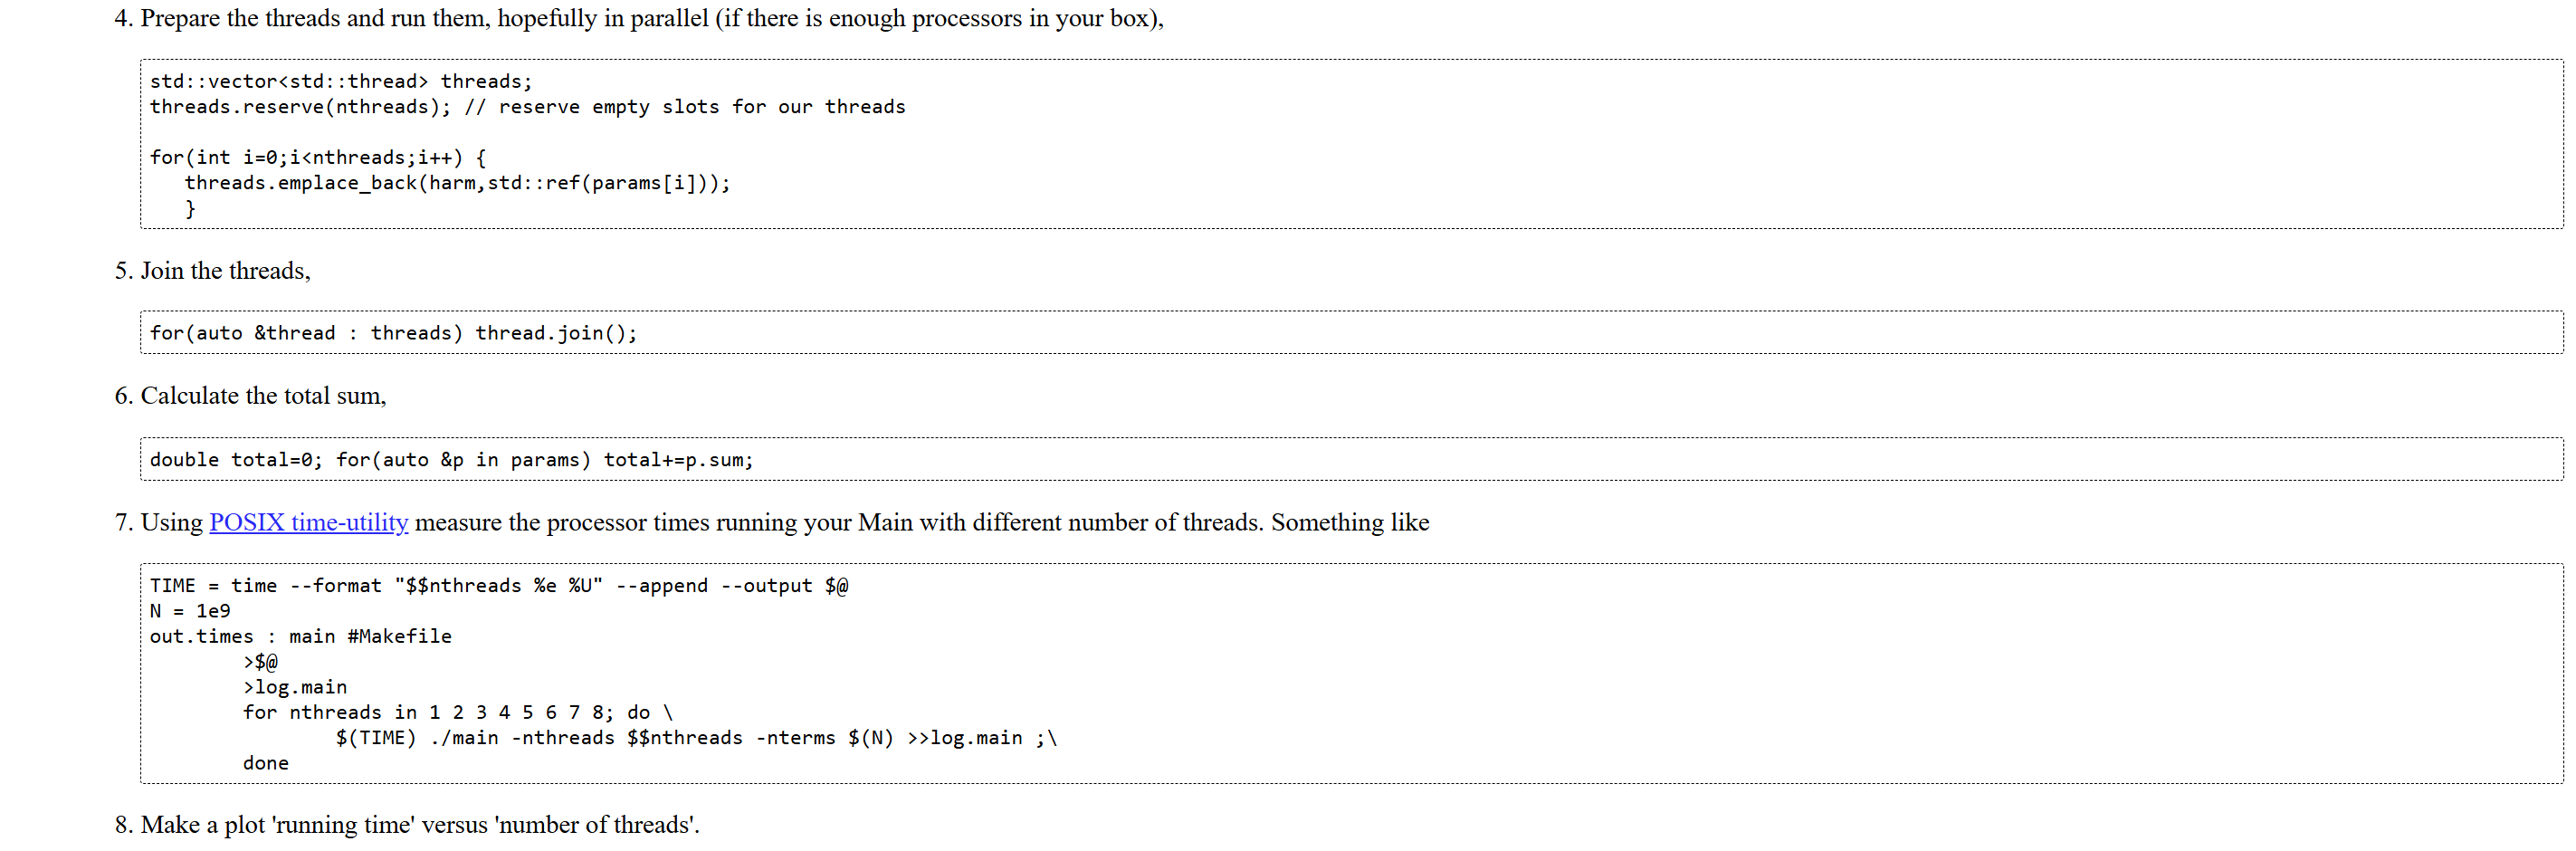

In [5]:
from pathlib import Path

Path("multiprocessing.cc").write_text(r'''
#include <cmath>
#include <cstdlib>
#include <iostream>
#include <iomanip>
#include <string>
#include <thread>
#include <vector>

struct data {
    long long a;
    long long b;
    double sum;
};

void harmonic_sum(data& arg) {
    long long a = arg.a;
    long long b = arg.b;

    double sum = 0.0;

    // Work with thread-local variable and write to memory only once
    for (long long i = a; i < b; ++i) {
        sum += 1.0 / i;
    }

    arg.sum = sum;
}

int main(int argc, char** argv) {
    int nthreads = 1;
    long long nterms = 300000000; // default value

    for (int i = 1; i < argc; ++i) {
        std::string arg = argv[i];

        if (arg == "-threads" && i + 1 < argc) {
            nthreads = std::stoi(argv[++i]);
        }

        if (arg == "-terms" && i + 1 < argc) {
            nterms = std::stoll(argv[++i]);
        }
    }

    if (nthreads < 1) {
        std::cerr << "number of threads must be positive\n";
        return 1;
    }

    std::vector<data> params(nthreads);

    for (int i = 0; i < nthreads; ++i) {
        params[i].a = 1 + nterms/nthreads*i;
        params[i].b = 1 + nterms/nthreads*(i + 1);
        params[i].sum = 0.0;
    }

    // Make sure the last thread reaches the correct endpoint
    params[nthreads - 1].b = nterms + 1;

    std::vector<std::thread> threads;
    threads.reserve(nthreads);

    for (int i = 0; i < nthreads; ++i) {
        threads.emplace_back(harmonic_sum, std::ref(params[i]));
    }

    for (auto& thread : threads) {
        thread.join();
    }

    double total = 0.0;

    for (const auto& p : params) {
        total += p.sum;
    }

    std::cout << std::setprecision(16);
    std::cout << "Exercise multiprocessing\n";
    std::cout << "========================\n\n";
    std::cout << "number of terms   = " << nterms << "\n";
    std::cout << "number of threads = " << nthreads << "\n";
    std::cout << "harmonic sum      = " << total << "\n";

    return 0;
}
''')

print("Wrote multiprocessing.cc")

Wrote multiprocessing.cc


In [7]:
import subprocess

compile_cmd = [
    "g++",
    "-std=c++23",
    "-O2",
    "-Wall",
    "-Wextra",
    "-pthread",
    "multiprocessing.cc",
    "-o",
    "multiprocessing"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    run = subprocess.run(
        ["./multiprocessing", "-threads", "4", "-terms", "30000000"],
        text=True,
        capture_output=True
    )

    print("Program output:")
    print(run.stdout)
    print(run.stderr)
else:
    print("Compilation failed.")

Compiler output:


Program output:
Exercise multiprocessing

number of terms   = 30000000
number of threads = 4
harmonic sum      = 17.79392362119365




In [8]:
import subprocess
from pathlib import Path

NTERMS = 300000000
thread_values = [1, 2, 3, 4, 5, 6, 7, 8]

rows = []

for nthreads in thread_values:
    cmd = [
        "/usr/bin/time",
        "-f",
        "%e",
        "./multiprocessing",
        "-threads",
        str(nthreads),
        "-terms",
        str(NTERMS)
    ]

    r = subprocess.run(cmd, text=True, capture_output=True)

    if r.returncode != 0:
        print("Run failed for", nthreads, "threads")
        print(r.stdout)
        print(r.stderr)
        continue

    # /usr/bin/time writes timing result to stderr
    time_seconds = float(r.stderr.strip().splitlines()[-1])

    rows.append((nthreads, time_seconds))

    print(f"threads = {nthreads:2d}, time = {time_seconds:.4f} s")

with open("multiprocessing_times.data", "w") as f:
    for nthreads, time_seconds in rows:
        f.write(f"{nthreads} {time_seconds}\n")

print("Wrote multiprocessing_times.data")

threads =  1, time = 0.3400 s
threads =  2, time = 0.2200 s
threads =  3, time = 0.1000 s
threads =  4, time = 0.0700 s
threads =  5, time = 0.0700 s
threads =  6, time = 0.0600 s
threads =  7, time = 0.0500 s
threads =  8, time = 0.0500 s
Wrote multiprocessing_times.data


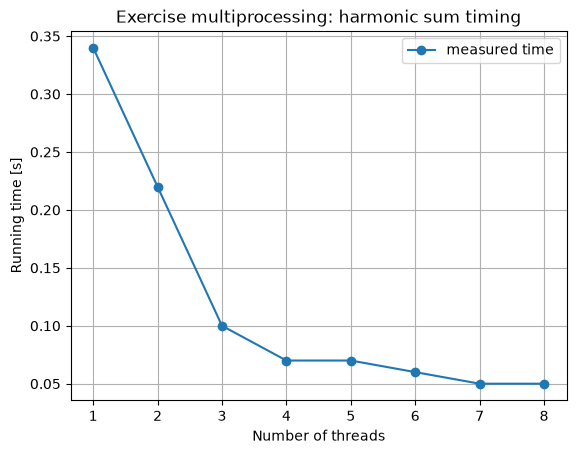

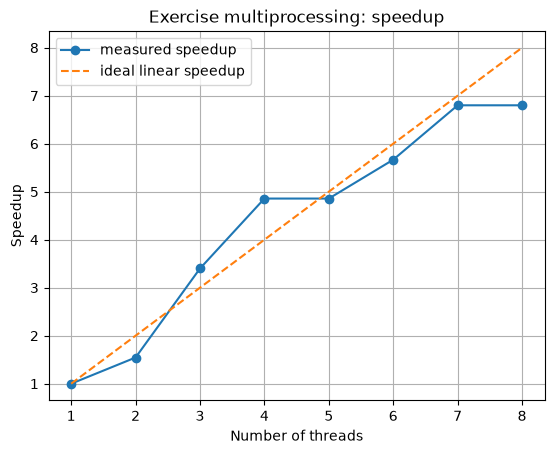

Timing results:
threads =  1, time = 0.3400 s, speedup = 1.000
threads =  2, time = 0.2200 s, speedup = 1.545
threads =  3, time = 0.1000 s, speedup = 3.400
threads =  4, time = 0.0700 s, speedup = 4.857
threads =  5, time = 0.0700 s, speedup = 4.857
threads =  6, time = 0.0600 s, speedup = 5.667
threads =  7, time = 0.0500 s, speedup = 6.800
threads =  8, time = 0.0500 s, speedup = 6.800


In [9]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("multiprocessing_times.data")

threads = data[:, 0]
times = data[:, 1]

plt.figure()
plt.plot(threads, times, "o-", label="measured time")
plt.xlabel("Number of threads")
plt.ylabel("Running time [s]")
plt.title("Exercise multiprocessing: harmonic sum timing")
plt.grid(True)
plt.legend()
plt.show()

speedup = times[0] / times

plt.figure()
plt.plot(threads, speedup, "o-", label="measured speedup")
plt.plot(threads, threads, "--", label="ideal linear speedup")
plt.xlabel("Number of threads")
plt.ylabel("Speedup")
plt.title("Exercise multiprocessing: speedup")
plt.grid(True)
plt.legend()
plt.show()

print("Timing results:")
for n, t, s in zip(threads, times, speedup):
    print(f"threads = {int(n):2d}, time = {t:.4f} s, speedup = {s:.3f}")

## Exercise "multiprocessing" conclusion

In this exercise the harmonic sum

$$
\sum_{i=1}^{n}\frac{1}{i}
$$

was calculated using manual multithreading in C++.

The summation interval was divided into subintervals, and each thread calculated one partial sum using a local variable. After all threads had finished, the partial sums were added together to obtain the final harmonic sum.

The program was tested with different numbers of threads. For $n=30000000$ terms, the running time decreased from about $0.34\,\mathrm{s}$ with one thread to about $0.05\,\mathrm{s}$ with seven or eight threads. This corresponds to a maximum measured speedup of about $6.8$.

The speedup is close to linear for some thread counts, but it is not perfectly linear. This is expected because of thread creation overhead, operating-system scheduling, cache effects, and the finite number of available CPU cores. The plateau between some thread counts shows that adding more threads does not always improve the running time proportionally.

Overall, the exercise demonstrates that the harmonic sum can be parallelized successfully using `std::thread`, and that the performance improves when the computational work is distributed over several threads.